In [2]:
# This notebook explain How I prepared the data .
# This notebook documents the data cleaning (handling datatype investigating missing data then imputing as and when required )and feature engineering process applied to the raw London Airbnb quarterly dataset. 
# It focuses on improving data quality, handling missing values, standardizing fields, and creating analytical features  required for downstream business analysis.
# Author :Sonali Patel
 

import pandas as pd
import numpy as np
import re
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import warnings
from sqlalchemy import create_engine
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", 300) 

Combining 4 quarterly snapshots (Q3 2024 to Q2 2025) into a unified dataset using UNION ALL.

All columns are explicitly listed to ensure schema consistency across quarters.

In [3]:
engine = create_engine(
    "mssql+pyodbc://LAPTOP-TG4UPAEV\SQLEXPRESS/London Airbnb?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)


airbnb_summary=pd.read_sql("""
WITH airbnb_summary AS (

SELECT
id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,
host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,
host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,
longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,
minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,
has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,
number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,
review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,
calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,'2024Q3' AS quarter
FROM dbo.London_6_sep_2024_listings_final

UNION ALL

SELECT
id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,
host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,
host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,
longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,
minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,
has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,
number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,
review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,
calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,'2024Q4' AS quarter
FROM dbo.London_11_December_2024_listings_final

UNION ALL

SELECT
id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,
host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,
host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,
longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,
minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,
has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,
number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,
review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,
calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,'2025Q1' AS quarter
FROM dbo.London_4_March_2025_listings_final

UNION ALL

SELECT
id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,
host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,
host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,
longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,
minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,
has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,
number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,
review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,
calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,'2025Q2' AS quarter
FROM dbo.London_10_June_2025_listings_final)

select 
id, host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,
host_listings_count,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,
longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,
minimum_nights,maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,
has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,
number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,
review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,
review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,
calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter
from airbnb_summary

""",engine)

airbnb_summary.head()


<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_333484\1482556436.py:2: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  "mssql+pyodbc://LAPTOP-TG4UPAEV\SQLEXPRESS/London Airbnb?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter
0,13913,54730,2009-11-16,within an hour,100%,77%,t,3.0,4.0,t,Islington,51.56861,-0.11270,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,$59.00,1,29,29.0,1.0,29.0,t,28,58,88,363,44,4,0,2010-08-18,2024-07-10,4.82,4.74,4.74,4.77,4.84,4.72,4.72,3,2,1,0,0.26,2024Q3
1,392141,1961043,2012-03-18,within a few hours,100%,60%,t,1.0,1.0,t,Wandsworth,51.44355,-0.19915,Private room in home,Private room,2,1.0,1 bath,1.0,1.0,$65.00,2,50,50.0,2.0,50.0,t,0,0,21,289,28,5,0,2012-05-07,2024-06-16,4.88,4.93,4.89,5.00,5.00,4.81,4.81,1,0,1,0,0.19,2024Q3
2,15400,60302,2009-12-05,N/A,N/A,100%,f,1.0,1.0,t,Kensington and Chelsea,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,$120.00,4,30,30.0,4.0,30.0,t,0,0,0,244,96,2,0,2009-12-21,2024-04-28,4.80,4.86,4.88,4.88,4.84,4.93,4.75,1,1,0,0,0.54,2024Q3
3,33332,144444,2010-06-14,N/A,N/A,N/A,f,2.0,2.0,f,Richmond upon Thames,51.46410,-0.32498,Private room in home,Private room,2,1.0,1 private bath,1.0,1.0,$140.00,2,21,21.0,2.0,21.0,t,30,60,90,365,19,0,0,2010-10-16,2022-08-01,4.37,4.44,4.56,4.56,4.50,4.67,4.22,2,0,2,0,0.11,2024Q3
4,493394,2437571,2012-05-22,N/A,N/A,N/A,f,1.0,1.0,f,Greenwich,51.50972,0.11894,Private room in rental unit,Private room,1,1.0,1 bath,1.0,1.0,$75.00,1,1125,1125.0,1.0,1125.0,t,30,60,90,365,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3


In [4]:
airbnb_summary.shape[0]

382536

In [5]:
# Quick overview of column datatypes and non-null counts
airbnb_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382536 entries, 0 to 382535
Data columns (total 49 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   id                                            382536 non-null  int64         
 1   host_id                                       382536 non-null  int64         
 2   host_since                                    382429 non-null  datetime64[ns]
 3   host_response_time                            382429 non-null  object        
 4   host_response_rate                            382429 non-null  object        
 5   host_acceptance_rate                          382429 non-null  object        
 6   host_is_superhost                             375710 non-null  object        
 7   host_listings_count                           382429 non-null  float64       
 8   host_total_listings_count                     382429 n

In [6]:
# Duplicate Check
# Since data spans 4 quarters (Q3 2024 - Q2 2025), the same listing ID 
# appearing across different quarters is expected and not a duplicate.
# A true duplicate = same listing ID appearing more than once in the same quarter.
# Result: 0 true duplicates confirms data integrity across all quarters.

duplicate_count = airbnb_summary.duplicated(subset=['id', 'quarter']).sum()
print(f"True duplicates (same listing, same quarter): {duplicate_count}")

if duplicate_count == 0:
    print("No duplicates found. No removal required. Data integrity confirmed.")

True duplicates (same listing, same quarter): 0
No duplicates found. No removal required. Data integrity confirmed.


### Missing data Investigation

In [7]:
# calculating the NaN count ,NaN percentage to deal with missing values 
n = len(airbnb_summary)

missing_summary = pd.DataFrame({
    'NaN_Count': airbnb_summary.isna().sum(),
    'NaN_Percentage': (airbnb_summary.isna().sum() / n) * 100,
    'DataType': airbnb_summary.dtypes
})

missing_summary = missing_summary.sort_values('NaN_Percentage', ascending=False)
print(missing_summary)


                                              NaN_Count  NaN_Percentage        DataType
beds                                             133847       34.989387         float64
bathrooms                                        133602       34.925340         float64
price                                            133529       34.906257          object
review_scores_location                            98711       25.804369         float64
review_scores_value                               98710       25.804107         float64
review_scores_checkin                             98706       25.803062         float64
review_scores_communication                       98611       25.778227         float64
review_scores_accuracy                            98587       25.771953         float64
review_scores_cleanliness                         98560       25.764895         float64
reviews_per_month                                 98523       25.755223         float64
first_review                    

- ***host_since,host_response_time,host_response_rate,host_acceptance_rate,host_listings_count
,host_total_listings_count,host_identity_verified***- all have same number of missing value % and missing value count suggesting that this is not random missingness.(These listings don’t have host metadata available (not scraped )) .
- ***In order to verify this we'll next have a look at the count and the sample subset of the rows where all of these columns together have missing values and will alos confirm that thhe subset obtained has same number of row count as returned by the above cell.***

In [8]:
# Verifying that all host related columns ( missing together)
subset = airbnb_summary[
    airbnb_summary[['host_since','host_response_time',
                    'host_identity_verified',
                    'host_acceptance_rate',
                    'host_response_rate',
                    'host_listings_count',
                    'host_total_listings_count']].isna().all(axis=1)]
print("Count:", subset.shape[0])
subset.head(3)


Count: 107


,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter
15871,5811550,8317501,NaT,None,None,None,f,NaN,NaN,None,Tower Hamlets,51.52512,-0.06566,Private room in home,Private room,1,NaN,1.5 baths,NaN,NaN,None,1,1125,1125.0,1.0,1125.0,t,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3
16879,7007873,22047056,NaT,None,None,None,f,NaN,NaN,None,Westminster,51.49459,-0.13414,Private room in rental unit,Private room,2,NaN,1 bath,NaN,NaN,None,8,1125,1125.0,8.0,1125.0,None,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3
17497,7595146,39828462,NaT,None,None,None,f,NaN,NaN,None,Tower Hamlets,51.48730,-0.01428,Private room in home,Private room,2,NaN,1 bath,NaN,NaN,None,1,1125,1125.0,1.0,1125.0,None,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3


- Since all 7 host columns are missing together for the same 107 rows, 

  this is ***Structural/Non-Random Missingness (MNAR - Missing Not At Random).***
- This means the imight be host metadata was never scraped/available for these listings,

  not that the data was lost or corrupted.
- Therefore imputing these values would be misleading — we preserve the 

  missingness signal by creating a binary flag instead.

- Creating a flag column first before any imputation, because imputing first 

  would cause us to lose the information that data was missing entirely.
  
  Preserving missingness as a signal is more analytically valuable than filling it.

In [9]:
host_cols = [
    'host_since','host_response_time','host_identity_verified',
    'host_acceptance_rate','host_response_rate',
    'host_listings_count','host_total_listings_count'
]

# Creating a Missing flag 
# Flag = 1 if ALL host columns are missing together, 0 otherwise
airbnb_summary['host_info_missing_flag'] = (
    airbnb_summary[host_cols].isna().all(axis=1)
).astype(int)


In [10]:
# unique values in each column
print(airbnb_summary['host_response_time'].unique())
print(airbnb_summary['host_identity_verified'].unique())
print(airbnb_summary['host_is_superhost'].unique())

['within an hour' 'within a few hours' 'N/A' 'within a day'
 'a few days or more' None]
['t' 'f' None]
['t' 'f' None]


- ***columns 'host_response_rate','host_identity_verified','host_is_superhost' with nan will be imputed with unknown as this willl later help analyze revenue and occupancy relation with host_respone and host identity verification***
- ***columns -> 'host_since','host_acceptance_rate','host_response_rate','host_listings_count','host_total_listings_count'*** have missing values -> wont be imputing -> why ?-> because host info actually missing → but after imputation it's misleading

In [11]:
# - 'unknown' is used instead of median/mode because these are categorical columns — preserving the fact that response time/verification status  was not available is more meaningful than assuming a value.

cols = ['host_response_rate','host_identity_verified','host_is_superhost']
# inputing values in cols
airbnb_summary[cols] = (
    airbnb_summary[cols]
        .replace('N/A', 'unknown')   # replace string N/A
        .fillna('unknown')           # replace None/NaN
        )

In [12]:
# Verify no NaN remaining in these columns
print(airbnb_summary[cols].isna().sum())

host_response_rate        0
host_identity_verified    0
host_is_superhost         0
dtype: int64


#### ***Analysing review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value missingness***

**Meaning of Review Score Columns**

1. **review_scores_accuracy**-Average guest rating of how accurate the listing description/photos are.
2. **review_scores_cleanliness**- Average guest rating of cleanliness.
3. **review_scores_checkin**- Average guest rating of ease of check-in process.
4. **review_scores_communication**-Average guest rating of host communication.
5. **review_scores_location**- Average guest rating of location quality.
6. **review_scores_value**- Average guest rating of value-for-money.
7. **review_scores_rating**- Overall average rating of the listing.(Overall, how was your stay?)
8. **reviews_per_month**- Average number of reviews received per month.(total_review/ month_since_first_review)
- **review_scores_rating**- Quality Metrics(satisfaaction).
- **reviews_per_month**- Demand Metrics (Popularity).

All these are already aggregated averages per listing by airbnb.
Airbnb doesn’t give  each individual guest review — they give the current average score for that listing.

Columns
1. review_scores_rating (**25.755223%** missing value)
2. reviews_per_month (**25.755223%** missing value)
3. review_scores_accuracy (**25.771953%** missing value)
4. review_scores_cleanliness (**25.764895%** missing value)
5. review_scores_checkin (**25.803062%** missing value)
6. review_scores_communication (**25.778227%** missing value)
7. review_scores_location (**25.804369%** missing value)
8. review_scores_value (**25.804107%** missing value)

***All of them have around 98,000 missing values, and total rows in dataset is 3,82,000 .If they are dropped we'll loose data for analysis so we'll try n find another way .***
- All 8 columns have approximately the same missing % (~25.7%) suggesting they are missing together — likely listings with no reviews at all.This will be verified in the next cell.

In [13]:
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month','first_review','last_review']

subset = airbnb_summary[ airbnb_summary[review_cols].isna().all(axis=1)]

count = subset.shape[0]
print(count)
if (count == 98523):
   print('Yes !, confirm they(all review columns value) are missing together.')
else:
   print('No !,they(all review columns value) are NOT missing together.')
subset.head()


98523
Yes !, confirm they(all review columns value) are missing together.


,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,price,minimum_nights,maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter,host_info_missing_flag
4,493394,2437571,2012-05-22,N/A,unknown,N/A,f,1.0,1.0,f,Greenwich,51.50972,0.11894,Private room in rental unit,Private room,1,1.0,1 bath,1.0,1.0,$75.00,1,1125,1125.0,1.0,1125.0,t,30,60,90,365,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3,0
8,127860,161720,2010-07-09,N/A,unknown,N/A,f,1.0,1.0,t,Richmond upon Thames,51.44777,-0.33962,Private room in home,Private room,2,NaN,1 shared bath,NaN,NaN,None,2,30,30.0,2.0,30.0,t,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3,0
11,576893,2837165,2012-07-05,N/A,unknown,N/A,f,1.0,1.0,f,Waltham Forest,51.55708,0.00855,Private room in home,Private room,2,NaN,3 baths,NaN,NaN,None,1,1125,1125.0,1.0,1125.0,None,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,2024Q3,0
14,590877,2915687,2012-07-12,N/A,unknown,N/A,f,3.0,3.0,t,Greenwich,51.47417,0.02622,Private room in rental unit,Private room,2,NaN,None,1.0,NaN,None,1,1125,1125.0,1.0,1125.0,t,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,3,0,NaN,2024Q3,0
16,5004143,23861587,2014-11-17,N/A,unknown,N/A,f,1.0,3.0,t,Newham,51.54185,0.05708,Entire rental unit,Entire home/apt,2,NaN,1 bath,1.0,NaN,None,2,30,30.0,2.0,30.0,t,0,0,0,0,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN,2024Q3,0


- ***columns like review_scores_rating,reviews_per_month,first_review,last_review all depend on having reviews or if reveiws are actually present in real .Since,there are no reviews that's not missing data.***
- ***If we'll impute them either with median or mode -> will be like creating fake review.This will breaks averages ,distibution,ML models,business_insights.***
- ***The above cell code confirms that they are all missing together in 98,523 rows .We'll create a flag 'no_reviews_flag' in cell below.***

In [14]:
# Flag = 1 if listing has no reviews at all, 0 otherwise
# These listings have never been reviewed — missingness is structural not random
airbnb_summary['no_reviews_flag'] = (airbnb_summary[review_cols].isna().all(axis=1)).astype(int)

- Imputing reviews_per_month NAN values with 0 ***because*** other reviews column that help derive this column value have no values /NaN present.If no reviews true value=0 ,this is logical.
- But for other columns like review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,first_review,last_review missingness.
- We'll leave NaN as it is because NaN means not reviewed /not occured/not available yet .So imputing 0 will probabaly means bad performance and that's not the possibility in reality as rating is between (1 - 5).
- Also for analysis/aggregation,pandas automatically ingore nulls.
- “Missing → carries business meaning”.So we preserve the meaning, not blindly impute.

In [15]:
airbnb_summary['reviews_per_month'] = airbnb_summary['reviews_per_month'].fillna(0)

In [16]:
# Verify reviews_per_month has no remaining NaN
print(f"Remaining NaN in reviews_per_month: {airbnb_summary['reviews_per_month'].isna().sum()}")

Remaining NaN in reviews_per_month: 0


***Beds*** have 34.92 % NaN values ,***bathrooms*** have 34.9 % Nan and ***bedrooms*** have 13.17% Nan.
- we'll look at distribution and  then decide how to impute NaN i.e using median or mean.

np.float64(3.4750077262503205)

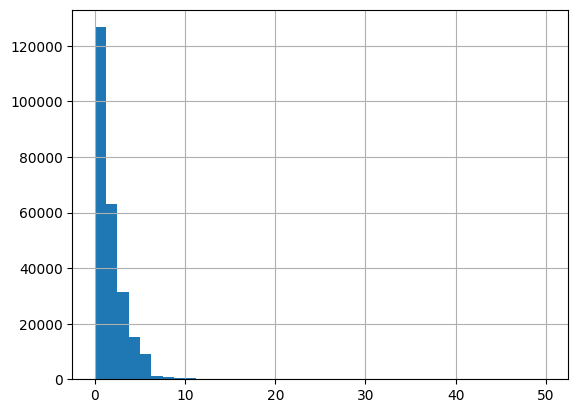

In [17]:
airbnb_summary['beds'].hist(bins=40)
airbnb_summary['beds'].skew()


IMPUTING BATHROOMS
- The column named ["bathrooms_text"] beside bathrooms has mentioned count in categorical way.
- This could help in imputing some missing value in ["bathrooms"] column.
- (e.g if [bathroom_text]="1 bath" ,then [bathrooms]="1")
- missing values in ["bathrooms"] = Number mentioned in ["bathrooms_text"] column

In [18]:
airbnb_summary["bathrooms"] = pd.to_numeric(airbnb_summary["bathrooms"], errors="coerce")

# Function to extract number of bathrooms from bathrooms_text
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan

    s = str(text).lower()

    # captures numbers like "1", "1.5", "2.5"
    m = re.search(r'(\d+(\.\d+)?)', s)
    if m:
        return float(m.group(1))

# Apply parsing, but only fill where bathrooms is NaN
mask_missing = airbnb_summary["bathrooms"].isna()
airbnb_summary.loc[mask_missing, "bathrooms"] = (
    airbnb_summary.loc[mask_missing, "bathrooms_text"].apply(parse_bathrooms)
)



In [19]:
airbnb_summary.drop('bathrooms_text',axis=1,inplace=True)

In [20]:
# after imputing bathroom missing values with help of bathrooms_text, we'll have a look at the missing value percentage 
missing2=(airbnb_summary['bathrooms'].isnull().sum()/len(airbnb_summary))*100
print(missing2)


0.32179977832151746


The above cell shows that after imputing Nan with help of bathrooms_text 0.32 %  values are still missing.
So,now we'll look at distribution to decide how to impute remianing NaN.

<Axes: >

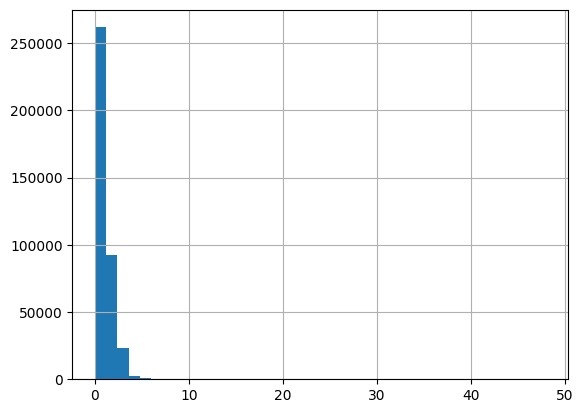

In [21]:
airbnb_summary['bathrooms'].hist(bins=40)

<Axes: xlabel='bedrooms'>

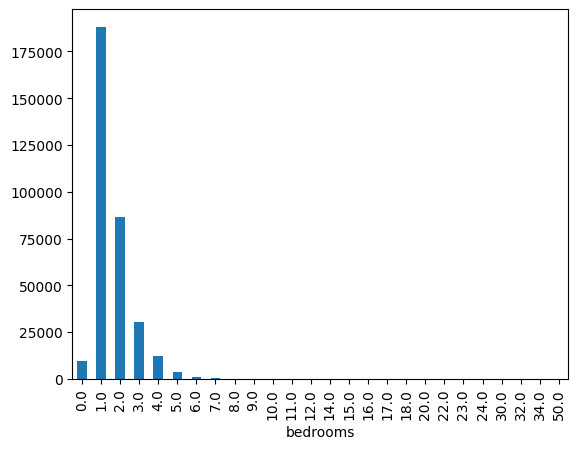

In [22]:
airbnb_summary['bedrooms'].value_counts().sort_index().plot(kind='bar')

Shape of column -'beds' distribution
- Very right skewed
- Most values → 1–3 beds
- Few → 5–10 beds
Very rare → 20–50 beds (extreme outliers)
- Because of outliner mean is inflated and median is stable
- ***Hence median is best here***
Because:
- robust to outliers
- keeps realistic bed count

In [23]:
# Imputing beds NaN with median (skewed distribution - robust to outliers)
airbnb_summary['beds'] = airbnb_summary['beds'].fillna(airbnb_summary['beds'].median())

Since distribution is: ***skewed***, Use MEDIAN to impute as Median is robust to outliers (better than mean).

In [24]:
airbnb_summary['bathrooms'].fillna(
    airbnb_summary['bathrooms'].median(),
    inplace=True
)

- Since bedroom distribution is skewed too impute using median but by using groupby property type and bedroom
- Grouping by property_type because bedroom count varies significantly by ***property type***— a studio vs a villa have very different typical bedroom counts.Global median would introduce bias.

In [27]:
import warnings

# Impute bedrooms using hierarchical groupby strategy
# Level 1: property_type + room_type + neighbourhood_cleansed (most granular)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    airbnb_summary['bedrooms'] = (
        airbnb_summary
        .groupby(['property_type', 'room_type', 'neighbourhood_cleansed'])['bedrooms']
        .transform(lambda x: x.fillna(x.median()))
    )
    
# Check remaining NaN
remaining = airbnb_summary['bedrooms'].isna().sum()
print(f"After neighbourhood groupby: {remaining} NaN remaining")

# Global median fallback for any remaining NaN
if remaining > 0:
    airbnb_summary['bedrooms'].fillna(
        airbnb_summary['bedrooms'].median(), inplace=True
    )
    print(f"After global median fallback: {airbnb_summary['bedrooms'].isna().sum()} NaN remaining")

After neighbourhood groupby: 0 NaN remaining


In [28]:
print(f"Remaining NaN in beds: {airbnb_summary['beds'].isna().sum()}")
print(f"Remaining NaN in bedrooms: {airbnb_summary['bedrooms'].isna().sum()}")

Remaining NaN in beds: 0
Remaining NaN in bedrooms: 0


### ***Analysing London_Airbnb's price column (34.906257 % missing values) and has_availability column (4.595907 % missing values)***
Price column has **34.906257%** missing values.
- Can't be dropped as this means lossing data.
- I'll try to figure out the reason of missingness and a legit way to impute missingness.
- Also deal with the price object datatype

In [30]:
# Price is stored as object dtype due to '$' and ',' characters in raw data
# Stripping non-numeric characters and converting to float

airbnb_summary["price"] = (
    airbnb_summary["price"]
    .astype(str)
    .str.replace(r"[^\d\.]", "", regex=True)   # remove $, commas, etc.
    .replace("", np.nan)
    .astype(float)
)


Total Rows:  382536    
Missing Price rows count: 133529 (34.906257 %)


In [31]:
# Verify price is now float
print(f"Price dtype after cleaning: {airbnb_summary['price'].dtype}")

Price dtype after cleaning: float64


* We need to think why price is empty is it MCAR(Missing completely at random) or NMAR(Not Missing at random)
- Investigating whether price missingness is MCAR or NMAR.
- MCAR (Missing Completely At Random): No pattern - missing values 
  are independent of any other variable.
- NMAR (Not Missing At Random): Missingness is related to other 
  variables - in this case has_availability and availability columns 
  could explain WHY price is missing.
- Hypothesis: Inactive/blocked listings may have no price set.
* There is a possibility that **"has_availability"** along **"availability_30","availability_60"**,**"availability_90"**,**"availability_365"** could indicate why price column has certain missing values.

In [35]:
# Total rows with price missing
total_missing = airbnb_summary[airbnb_summary["price"].isna()]

cols_to_show = [ "price", "has_availability", "availability_30", "availability_60", "availability_90", "availability_365"]

# Display the subset
print(total_missing[cols_to_show].head(5)) 

# Split by has_availability status
true_missing  = total_missing[total_missing["has_availability"] == "t"].shape[0]
false_missing = total_missing[total_missing["has_availability"] == "f"].shape[0]
nan_missing   = total_missing[total_missing["has_availability"].isna()].shape[0]

print("Price missing & has_availability = t :", true_missing)
print("Price missing & has_availability = f :", false_missing)
print("Price missing & has_availability = NaN:", nan_missing)


    price has_availability  availability_30  availability_60  availability_90  availability_365
8     NaN                t                0                0                0                 0
11    NaN             None                0                0                0                 0
14    NaN                t                0                0                0                 0
16    NaN                t                0                0                0                 0
17    NaN             None                0                0                0                 0
Price missing & has_availability = t : 119118
Price missing & has_availability = f : 142
Price missing & has_availability = NaN: 14269


sample dataframe with Price="NaN"

***Investigating 'Price' Not Missing at Random (NMAR)***

- has_availability=The listing is still on the platform, not suspended or deleted. Guests could book it if the host opened their calendar.This means the listing is technically active but functionally unavailable.
- availability_30, availability_60, availability_90, availability_365 (numeric counts)
These show how many days are actually open for booking in those time windows.
Example:
availability_30 = 15 → listing open 15 days in the next 30.
availability_365 = 0 → no days available in the next year.

The above dataframe along with has_availability says that there exist 3 combinations 
1. price==null and has_availability =True
2. price==null and has_availability =False
3. price==null and has_availability =NaN
 
Indicating it's (not missing at random, NMAR).

It is likely that most of them might also be missing reviews and host info too .We check in below code using the flag columns that were created earler -> 'host_info_missing_flag','no_reviews_flag'.

**Combination_1** price = Nan ,has_availability = True ,and all availability_30,availability_60,availability_90,availability_365 as > 0 values

or **price = NaN, has_availability = t, availability columns > 0**
- Airbnb says listing is active (t) are bookable.
- Calendar shows bookable days.future open days (availability_x > 0).
- But price is missing. (It is likely that most of them might also be missing reviews and host info too).We check in below code.
- Interpretation: Likely a scrape gap (the price wasn’t captured during scraping)/ partial record capture. These are truly active listings → Missing  value imputation for price could be done (by room_type + neighbourhood).
- Using flag columns created earlier (host_info_missing_flag, no_reviews_flag) to cross-validate whether price-missing listings also lack host and review data 
— this would further confirm NMAR pattern.

Truly active listings on airbnb so imputation is justified.

In [36]:
# Filter rows where: price = NaN, has_availability = "t, and all availability_x columns > 0
blocked_price_null_0 = airbnb_summary[
    (airbnb_summary["price"].isna()) &
    (airbnb_summary["has_availability"] == "t") &
    (airbnb_summary["availability_30"] > 0) &
    (airbnb_summary["availability_60"] > 0) &
    (airbnb_summary["availability_90"] > 0) &
    (airbnb_summary["availability_365"] > 0)
]

# Columns to display
cols_to_show = [
    "price", "has_availability", "availability_30", "availability_60", "availability_90", "availability_365"]

# Show row count
print("Listings with Price=NaN, has_availability=t, and all availability columns>0:",blocked_price_null_0.shape[0])

review_zero_count = blocked_price_null_0[
    blocked_price_null_0["no_reviews_flag"] == 0
].shape[0]

host_zero_count = blocked_price_null_0[
    blocked_price_null_0["host_info_missing_flag"] == 0
].shape[0]

print("Rows with review flag(missing) = 0:", review_zero_count)
print("Rows with host info(missing) = 0:", host_zero_count)
# Display the dataframe with only 6 required columns
display(blocked_price_null_0[cols_to_show].head())
# blocked_price_null_0.head()



Listings with Price=NaN, has_availability=t, and all availability columns>0: 11596
Rows with review flag(missing) = 0: 8321
Rows with host info(missing) = 0: 11596


,price,has_availability,availability_30,availability_60,availability_90,availability_365
18,NaN,t,23,25,25,25
38,NaN,t,1,2,3,3
69,NaN,t,29,59,89,269
100,NaN,t,28,58,88,363
240,NaN,t,30,60,90,90


**Combination_2** with Price= Nan ,has_availability as True ,and all availability_30,availability_60,availability_90,availability_365 as 0 values

or **price = NaN, has_availability = t, availability columns = 0**
- Total row count with this combination = 104455
- Reviews flag = 0 → 76,423
- Host info missing = 104,455(almost all)
- Airbnb says listing is Technically active.
- But calendar completely blocked/shows no open nights.
- Price missing.
- Almost all missing host info
- 76,423 listings actually have reviews — suggesting these were previously active listings now blocked/paused
- This is not normal active inventory.
- Interpretation: Listings are blocked/paused by host/Dormant listings/Shadow listings/Inactive hosts/Scraped but not fully populated. 
They’re technically active but functionally unavailable.
These should be labeled “Blocked/Inactive” →  no imputation of price,
-  ***Either keep as NaN or drop these or create a feature marking each listing as active or inactive***. Why?
- ***As imputing will create fake supply,fake pricing distribution,lower variance,bias in neighbourhood medians ,this seems statistically dangerous.***
- These are NOT normal revenue-generating listings.

In [37]:
# Filter rows where:price = NaN, has_availability = "t", and all availability_x columns = 0
blocked_price_null_1 = airbnb_summary[
    (airbnb_summary["price"].isna()) & 
    (airbnb_summary["has_availability"] == "t") &
    (airbnb_summary["availability_30"] == 0) &
    (airbnb_summary["availability_60"] == 0) &
    (airbnb_summary["availability_90"] == 0) &
    (airbnb_summary["availability_365"] == 0)
]

# Columns to display
cols_to_show = ["id","price","has_availability","availability_30","availability_60","availability_90","availability_365"]

# Show row count
print("Listings with Price=NaN, has_availability=t, and all availability columns=0:", blocked_price_null_1.shape[0])
blocked_price_null_1.head()
review_zero_count = blocked_price_null_1[
    blocked_price_null_1["no_reviews_flag"] == 0
].shape[0]

host_zero_count = blocked_price_null_1[
    blocked_price_null_1["host_info_missing_flag"] == 0
].shape[0]
print("Rows with review flag(missing)= 0:", review_zero_count)
print("Rows with host info(missing) = 0:", host_zero_count)

# Display the dataframe with only 6 columns
display(blocked_price_null_1[cols_to_show].head())
# blocked_price_null_1.head()


Listings with Price=NaN, has_availability=t, and all availability columns=0: 104487
Rows with review flag(missing)= 0: 76423
Rows with host info(missing) = 0: 104455


,id,price,has_availability,availability_30,availability_60,availability_90,availability_365
8,127860,NaN,t,0,0,0,0
14,590877,NaN,t,0,0,0,0
16,5004143,NaN,t,0,0,0,0
23,33175029,NaN,t,0,0,0,0
27,39387,NaN,t,0,0,0,0


**Combination_3**= **price = NaN, has_availability = f, availability columns = 0**

- Airbnb says listing is inactive.
- No availability.
- Price missing.
Interpretation: These are truly inactive listings.

Treat as “Inactive” → keep NaN price (don’t impute).

In [38]:
# Filter rows where: price = NaN, has_availability = "f" and all availability_x columns = 0
blocked_price_null_2 = airbnb_summary[
    (airbnb_summary["price"].isna()) &
    (airbnb_summary["has_availability"] == "f") &
    (airbnb_summary["availability_30"] == 0) &
    (airbnb_summary["availability_60"] == 0) &
    (airbnb_summary["availability_90"] == 0) &
    (airbnb_summary["availability_365"] == 0)
]

# Columns to display
cols_to_show = ["price","has_availability","availability_30","availability_60","availability_90","availability_365"]

# Show row count
print("Listings with Price=NaN, has_availability=f, and all availability columns=0:",blocked_price_null_2.shape[0])
review_zero_count = blocked_price_null_2[
    blocked_price_null_2["no_reviews_flag"] == 0
].shape[0]

host_zero_count = blocked_price_null_2[
    blocked_price_null_2["host_info_missing_flag"] == 0
].shape[0]
print("Rows with review flag(missing)= 0:", review_zero_count)
print("Rows with host info(missing) = 0:", host_zero_count)

# Display the dataframe with only 6 columns
display(blocked_price_null_2[cols_to_show].head())
# blocked_price_null_2.head()

Listings with Price=NaN, has_availability=f, and all availability columns=0: 142
Rows with review flag(missing)= 0: 98
Rows with host info(missing) = 0: 142


,price,has_availability,availability_30,availability_60,availability_90,availability_365
1150,NaN,f,0,0,0,0
12005,NaN,f,0,0,0,0
14442,NaN,f,0,0,0,0
16127,NaN,f,0,0,0,0
16659,NaN,f,0,0,0,0


**Combination_4**= **price = NaN, has_availability = NaN, availability columns vary ( >0)**

- No info about host’s availability flag.
- Some still have days open, some don’t.
- Interpretation: These are ambiguous/unclassified cases.
- Could be due to data scraping issues.

Handle separately as “Unknown Status/inactive”.

In [39]:
# Filter rows where price is NaN, has_availability is NaN and at least one availability_x column > 0
price_na_avail_na_active = airbnb_summary[
    (airbnb_summary["price"].isna()) &
    (airbnb_summary["has_availability"].isna()) &
    (
        (airbnb_summary["availability_30"] > 0) |
        (airbnb_summary["availability_60"] > 0) |
        (airbnb_summary["availability_90"] > 0) |
        (airbnb_summary["availability_365"] > 0)
    )
]

# Columns to display
cols_to_show = [ "price", "has_availability", "availability_30", "availability_60", "availability_90", "availability_365"]

# Row count
print("Listings with Price=NaN, has_availability=NaN, and some availability > 0:",price_na_avail_na_active.shape[0])
review_zero_count = price_na_avail_na_active[
    price_na_avail_na_active["no_reviews_flag"] == 0
].shape[0]

host_zero_count = price_na_avail_na_active[
    price_na_avail_na_active["host_info_missing_flag"] == 0
].shape[0]
print("Rows with review flag(missing)= 0:", review_zero_count)
print("Rows with host info(missing) = 0:", host_zero_count)
# Display DataFrame with only relevant columns
display(price_na_avail_na_active[cols_to_show].head())
# price_na_avail_na_active.head()


Listings with Price=NaN, has_availability=NaN, and some availability > 0: 150
Rows with review flag(missing)= 0: 1
Rows with host info(missing) = 0: 150


,price,has_availability,availability_30,availability_60,availability_90,availability_365
1809,NaN,None,29,59,89,269
3386,NaN,None,30,60,90,113
4125,NaN,None,30,60,90,365
5978,NaN,None,23,53,83,358
6129,NaN,None,30,60,90,365


Action for each category
## **Conclusion**

**“We segmented the ~133k listings with missing prices into four categories: Active, Blocked, Inactive, and Unknown.**
- Only the truly active and bookable listings were imputed (by quarter, accommodates, and neighbourhood). The rest were left as NaN to avoid overestimating active supply.”
- **Active** but Price Missing →no of rows imputed -**11596**, Impute price (group medians). 
- **Blocked/Inactive** → no of rows=104487, Keep price as NaN (listing is not usable right now).
- **Inactive** → no of rows = 142, Keep price as NaN (listing is gone).
- **Unknown/Inactive** → no of rows = 150, Possible Option could be impute or exclude from KPIs, but keep flagged separately.


Finally arriving at Impute Missing Prices for active listings or Combination 1 ->rows where: price = NaN, has_availability = "t, and all availability_x columns > 0 o

-Impute using a hierarchy of medians:
- Group median by room_type  + neighbourhood_cleansed

In [ ]:

# Creating listing_status feature based on availability_365
# Active = at least 1 day available in the next year
# Inactive = completely blocked/unavailable (availability_365 = 0)
airbnb_summary["listing_status"] = np.where(airbnb_summary["availability_365"] > 0, "Active", "Inactive")

In [41]:
# Imputing price only for Active listings with missing price
# Using group median by neighbourhood_cleansed + room_type
# to reflect realistic local pricing patterns
mask = ((airbnb_summary["listing_status"] == "Active") & (airbnb_summary["price"].isna())) 

airbnb_summary.loc[mask, "price"] = (airbnb_summary.groupby(["neighbourhood_cleansed", "room_type"])["price"].transform("median"))

In [ ]:
# Verify no active listings have missing price remaining
active_price_null = airbnb_summary[(airbnb_summary["listing_status"] == "Active") & (airbnb_summary["price"].isna())].shape[0]
print(f"Active listings with price still missing: {active_price_null}")

Active listings with price still missing: 1


In [44]:
airbnb_summary.head()

,id,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,quarter,host_info_missing_flag,no_reviews_flag,listing_status
0,13913,54730,2009-11-16,within an hour,100%,77%,t,3.0,4.0,t,Islington,51.56861,-0.11270,Private room in rental unit,Private room,1,1.0,1.0,1.0,59.0,1,29,29.0,1.0,29.0,t,28,58,88,363,44,4,0,2010-08-18,2024-07-10,4.82,4.74,4.74,4.77,4.84,4.72,4.72,3,2,1,0,0.26,2024Q3,0,0,Active
1,392141,1961043,2012-03-18,within a few hours,100%,60%,t,1.0,1.0,t,Wandsworth,51.44355,-0.19915,Private room in home,Private room,2,1.0,1.0,1.0,65.0,2,50,50.0,2.0,50.0,t,0,0,21,289,28,5,0,2012-05-07,2024-06-16,4.88,4.93,4.89,5.00,5.00,4.81,4.81,1,0,1,0,0.19,2024Q3,0,0,Active
2,15400,60302,2009-12-05,N/A,unknown,100%,f,1.0,1.0,t,Kensington and Chelsea,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,120.0,4,30,30.0,4.0,30.0,t,0,0,0,244,96,2,0,2009-12-21,2024-04-28,4.80,4.86,4.88,4.88,4.84,4.93,4.75,1,1,0,0,0.54,2024Q3,0,0,Active
3,33332,144444,2010-06-14,N/A,unknown,N/A,f,2.0,2.0,f,Richmond upon Thames,51.46410,-0.32498,Private room in home,Private room,2,1.0,1.0,1.0,140.0,2,21,21.0,2.0,21.0,t,30,60,90,365,19,0,0,2010-10-16,2022-08-01,4.37,4.44,4.56,4.56,4.50,4.67,4.22,2,0,2,0,0.11,2024Q3,0,0,Active
4,493394,2437571,2012-05-22,N/A,unknown,N/A,f,1.0,1.0,f,Greenwich,51.50972,0.11894,Private room in rental unit,Private room,1,1.0,1.0,1.0,75.0,1,1125,1125.0,1.0,1125.0,t,30,60,90,365,0,0,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,0.00,2024Q3,0,1,Active


## Feature Engineering

Creating two analytical features for active listings only:
1. **occ_rate_30** — Occupancy rate based on 30-day availability window
2. **revenue_quarter** — Estimated quarterly revenue per listing

Note: These features are calculated only for active listings (price is not null)
as inactive listings do not generate revenue.

In [46]:
#  Creating a feature occ_rate_30 signifying the occupancy of active listings 
active = airbnb_summary[airbnb_summary["price"].notna()].copy()
active["occ_rate_30"] = (1 - active["availability_30"]/30).clip(0,1)
airbnb_summary.loc[active.index, "occ_rate_30"] = active["occ_rate_30"]
# Creating a feature reveue quarter
# revenue_quarter = price × occupancy_rate × 90 days
# Estimates quarterly revenue assuming current occupancy rate holds
active["revenue_quarter"] = active["price"] * active["occ_rate_30"] * 90
airbnb_summary.loc[active.index, "revenue_quarter"] = active["revenue_quarter"]


In [47]:
print(f"occ_rate_30 range: {active['occ_rate_30'].min()} - {active['occ_rate_30'].max()}")
print(f"revenue_quarter range: £{active['revenue_quarter'].min()} - £{active['revenue_quarter'].max()}")

occ_rate_30 range: 0.0 - 1.0
revenue_quarter range: £0.0 - £6669000.0


In [49]:
# Investigating maximum revenue listing
print(active[active['revenue_quarter'] == active['revenue_quarter'].max()]
      [['price', 'occ_rate_30', 'revenue_quarter', 'room_type','property_type', 'neighbourhood_cleansed']])

          price  occ_rate_30  revenue_quarter        room_type       property_type neighbourhood_cleansed
296163  74100.0          1.0        6669000.0  Entire home/apt  Entire rental unit              Islington


- occ_rate_30 range: 0.0 - 1.0 ( within expected bounds, clip worked correctly)
- revenue_quarter range: £0 - £6,669,000
- £0 minimum expected — listings with no bookings generate no revenue
- £6.6M maximum is plausible for ultra-luxury London properties 
    (e.g. entire mansion at £75,000/night × 100% occupancy × 90 days)
- These represent the extreme upper tail of London's luxury market
    and are genuine data points, not errors

In [50]:
airbnb_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382536 entries, 0 to 382535
Data columns (total 53 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   id                                            382536 non-null  int64         
 1   host_id                                       382536 non-null  int64         
 2   host_since                                    382429 non-null  datetime64[ns]
 3   host_response_time                            382429 non-null  object        
 4   host_response_rate                            382536 non-null  object        
 5   host_acceptance_rate                          382429 non-null  object        
 6   host_is_superhost                             382536 non-null  object        
 7   host_listings_count                           382429 non-null  float64       
 8   host_total_listings_count                     382429 n

In [ ]:
from sqlalchemy import create_engine, text

engine = create_engine(
    "mssql+pyodbc://LAPTOP-TG4UPAEV\\SQLEXPRESS/London Airbnb?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

create_table_query = """
CREATE TABLE dbo.airbnb_summary_final (
id Bigint , 
host_id int , 
host_since date, 
host_response_time varchar(50), 
host_response_rate varchar(50), 
host_acceptance_rate varchar(50),
host_is_superhost varchar(50), 
host_listings_count int,
host_total_listings_count int,
host_identity_verified varchar(50), 
neighbourhood_cleansed varchar(255),
latitude decimal(12,7),
longitude decimal(12,7), 
property_type varchar(255),
room_type varchar(255),
accommodates int,
bathrooms float, 
bedrooms float,
beds float,
price decimal(12,2), 
minimum_nights int,
maximum_nights int,
maximum_maximum_nights int ,
minimum_nights_avg_ntm float ,
maximum_nights_avg_ntm float,
has_availability nvarchar(50), 
availability_30 int, 
availability_60 int, 
availability_90 int,
availability_365 int, 
number_of_reviews int,
number_of_reviews_ltm int,
number_of_reviews_l30d int, 
first_review date, 
last_review date,
review_scores_rating float, 
review_scores_accuracy float,
review_scores_cleanliness float, 
review_scores_checkin float,
review_scores_communication float,
review_scores_location float,
review_scores_value float, 
calculated_host_listings_count int,
calculated_host_listings_count_entire_homes int,
calculated_host_listings_count_private_rooms  int, 
calculated_host_listings_count_shared_rooms int,
reviews_per_month float, 
quarter nvarchar(7), 
host_info_missing_flag nvarchar(3), 
no_reviews_flag nvarchar(3),
listing_status nvarchar(10), 
occ_rate_30 float,
revenue_quarter decimal(12,5)
)

"""

with engine.connect() as conn:
    conn.execute(text(create_table_query))
    conn.commit()


airbnb_summary.to_sql("airbnb_summary_final", engine, if_exists="append", index=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_131856\1083853603.py:66: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  with engine.connect() as conn:


24